# b-Value temporal estimation using MAXC

<div class="alert alert-block alert-warning">
need to change: <b>>RAW_DATA_FILE, OUTPUT_FILE, interval, smoothness</b>
</div>

<div class="alert alert-block alert-info">
The plots are customized based on start_plot and end_plot <br>
To edit saving plot : plt.savefig(f'GFT_plot_{i}.png', dpi=300, bbox_inches='tight')
</div>

No fits within confidence levels, using MAXC estimate for interval 0 to 10
No fits within confidence levels, using MAXC estimate for interval 7.5 to 17.5
No fits within confidence levels, using MAXC estimate for interval 127.5 to 137.5
No fits within confidence levels, using MAXC estimate for interval 225.0 to 235.0
No fits within confidence levels, using MAXC estimate for interval 315.0 to 325.0
No fits within confidence levels, using MAXC estimate for interval 352.5 to 362.5
No fits within confidence levels, using MAXC estimate for interval 390.0 to 400.0
No fits within confidence levels, using MAXC estimate for interval 427.5 to 437.5
No fits within confidence levels, using MAXC estimate for interval 457.5 to 467.5
No fits within confidence levels, using MAXC estimate for interval 502.5 to 512.5


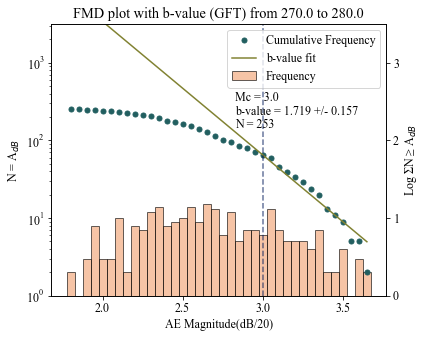

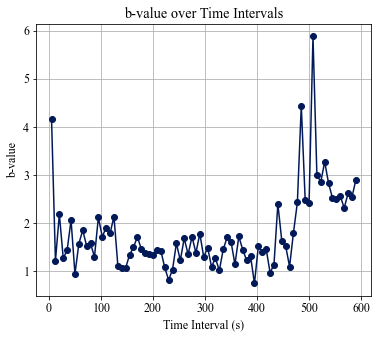

Lowest possible time interval with at least 50 hits: 10 seconds


In [1]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt

# Set plot size to be larger than default
plt.rcParams["figure.figsize"] = (6, 5)
plt.rcParams['font.family'] = 'serif'             # Set overall font family 
plt.rcParams['font.serif'] = ['Times New Roman']  # Try to prioritize Times New Roman
plt.rcParams.update({'legend.fontsize': 12})

font = {'family': 'serif',
        'size': 12}

plt.rc('font', **font)

# Constants / file-paths
RAW_DATA_FILE = 'AE-Filt-ch3.xlsx'  
OUTPUT_FILE = 'b-GFT-ch3-10s.xlsx'

# Read in the data
df = pd.read_excel(RAW_DATA_FILE)
df.columns = ['Time', 'Amplitude']

# Filter the data to include only rows where the time is less than 10 minutes
df = df[df['Time'] < 600.1]

# Divide amplitude by 20
df['Amplitude'] = df['Amplitude'] / 20

# Frequency-magnitude distribution function
def fmd(mag, mbin):
    minmag = math.floor(min(mag / mbin)) * mbin  # Lowest magnitude bin
    maxmag = math.ceil(max(mag / mbin)) * mbin  # Highest magnitude bin
    mi = np.arange(minmag, maxmag + mbin, mbin)  # Sequence of magnitude bins
    nbm = len(mi)  # No. of magnitude bins
    cumnbmag = np.zeros(nbm)  # Pre-allocate array for cumulative no. of events in mag bin and higher

    # Get cumulative no. of events in mag bin and higher
    for i in range(nbm):
        cumnbmag[i] = np.where(mag > mi[i] - mbin / 2)[0].shape[0]

    # Get no. of events in each mag bin:
    nbmag = abs(np.diff(np.append(cumnbmag, 0)))

    return mi, nbmag, cumnbmag  # Return magnitude bins, no. of events in bin, and cumulative no. of events

# Function to estimate b-value using maximum likelihood method
def b_est(mag, mbin, mc):
    mag_above_mc = mag[mag > round(mc, 1) - mbin / 2]  # Magnitudes for events larger than cut-off magnitude mc
    n = mag_above_mc.shape[0]  # No of. events larger than cut-off magnitude mc
    if n < 50:  # Ensure at least 50 events
        return np.nan, np.nan, np.nan, np.nan
    else:
        mbar = np.mean(mag_above_mc)  # Mean magnitude for events larger than cut-off magnitude mc
        b = math.log10(math.exp(1)) / (mbar - (mc - mbin / 2))  # b-value from Eq 3
        a = math.log10(n) + b * mc  # 'a-value' for Eq 2
        aki_unc = b / math.sqrt(n)  # Uncertainty estimate from Eq 4
        shibolt_unc = 2.3 * b ** 2 * math.sqrt(sum((mag_above_mc - mbar) ** 2) / (n * (n - 1)))  # Uncertainty estimate from Eq 5
        return a, b, aki_unc, shibolt_unc  # Return b-value and estimates of uncertainty

# Function to generate overlapping time intervals
def generate_intervals(start_time, end_time, interval_length, smoothing_percentage):
    intervals = []
    step = interval_length * (1 - smoothing_percentage)
    current_start = start_time
    while current_start + interval_length <= end_time:
        intervals.append((current_start, current_start + interval_length))
        current_start += step
    return intervals

# Function to get completeness magnitude with MAXC method
def get_maxc(mag, mbin):
    this_fmd = fmd(mag, mbin)  # FMD
    maxc = this_fmd[0][np.argmax(this_fmd[1])]  # Mag bin with highest no. of events
    return round(maxc, 1)

# Function to get completeness magnitude with GFT method
def get_gft(mag, mbin, interval):
    this_fmd = fmd(mag, mbin)  # FMD
    this_maxc = get_maxc(mag, mbin)  # Needed further down

    # Zeros to accommodate synthetic GR distributions for each magnitude bin
    a = np.zeros(this_fmd[0].shape[0])  # Pre-allocate array to accommodate a values from Eq 2
    b = np.zeros(this_fmd[0].shape[0])  # Pre-allocate array to accommodate b values from Eq 2 & 3
    R = np.zeros(this_fmd[0].shape[0])  # Pre-allocate array to accommodate R values from Eq 6

    # Loop through each magnitude bin, using it as cut-off magnitude
    for i in range(this_fmd[0].shape[0]):
        mi = round(this_fmd[0][i], 1)  # Cut-off magnitude
        try:
            a[i], b[i], tmp1, tmp2 = b_est(mag, mbin, mi)  # a and b-values for this cut-off magnitude
        except:
            continue
        synthetic_gr = 10**(a[i] - b[i]*this_fmd[0])  # Synthetic GR for a and b
        Bi = this_fmd[2][i:]  # B_i in Eq 6
        Si = synthetic_gr[i:]  # S_i in Eq 6
        R[i] = (sum(abs(Bi - Si)) / sum(Bi)) * 100  # Eq 6

    # Confidence levels to test
    R_to_test = [95, 90]  # (95% and 90% conf levels)

    GFT_test = [np.where(R <= (100 - conf_level))[0] for conf_level in R_to_test]  # Test whether R within confidence level
    mc = np.nan  # Initialize mc as NaN

    # Loop through and check first cut-off mag within confidence level
    for test in GFT_test:
        if len(test) > 0:
            mc = round(this_fmd[0][test[0]], 1)  # Use first cut-off magnitude within confidence level
            break

    if np.isnan(mc):  # If no GFT test passed, use MAXC
        mc = this_maxc
        print(f'No fits within confidence levels, using MAXC estimate for interval {interval[0]} to {interval[1]}')

    return mc, this_fmd[0], R

# Function to calculate b-values for specified intervals
def calculate_b_values(df, intervals, mbin=0.05):
    b_values = []
    for interval in intervals:
        start, end = interval
        subset = df[(df['Time'] >= start) & (df['Time'] < end)]
        if len(subset) >= 50:  # Ensure at least 50 hits
            mag = subset['Amplitude']
            cat_mi, cat_nbmag, cat_cumnbmag = fmd(mag, mbin)
            mc_gft, mag_bins, R_gft = get_gft(mag, mbin, interval)
            if np.isnan(mc_gft):
                mc_gft = get_maxc(mag, mbin)
            if mc_gft is not None:
                a, b, aki_unc, shibolt_unc = b_est(mag, mbin, mc_gft)
                b_values.append({
                    'start': start,
                    'end': end,
                    'a': a,
                    'b': b,
                    'aki_unc': aki_unc,
                    'shibolt_unc': shibolt_unc,
                    'mc': mc_gft,
                    'n': len(mag)
                })
    return b_values

# Function to plot b-values for specified intervals
def plot_b_values(b_values, start_plot, end_plot):
    for i, b_value in enumerate(b_values):
        if b_value['start'] >= start_plot and b_value['end'] <= end_plot:
            fig, ax1 = plt.subplots()
            mag = df[(df['Time'] >= b_value['start']) & (df['Time'] < b_value['end'])]['Amplitude']
            cat_mi, cat_nbmag, cat_cumnbmag = fmd(mag, 0.05)

            # Plot cat_nbmag as a bar chart
            ax1.bar(cat_mi, cat_nbmag, width=0.05, color='#f09d6b', edgecolor='black', linewidth=1, alpha=0.6, label='Frequency')

            # Superimpose the original plots
            ax1.plot(cat_mi, cat_cumnbmag, '.', markersize=10, label='Cumulative Frequency', color='#225f60')
            ax1.plot(cat_mi, (10 ** (b_value['a'] - (b_value['b'] * cat_mi))), label='b-value fit', color='#818232')

            # Vertical line for completeness magnitude
            ax1.vlines(b_value['mc'], ymin=1, ymax=10 ** math.ceil(math.log10(df.shape[0])), alpha=0.6, linestyles='dashed', color='#011959')

            # Set log scale for y-axis
            ax1.set_yscale('log')
            ax1.set_ylim(1, 10 ** 3.5)

            # Labels and title
            ax1.set_xlabel('AE Magnitude(dB/20)')
            ax1.set_ylabel('N = A$_{dB}$')
            ax1.set_title(f'FMD plot with b-value (GFT) from {b_value["start"]} to {b_value["end"]}')

            # Text annotations
            ax1.text(x=0.55, y=0.75, s=f"Mc = {round(b_value['mc'], 1)}", transform=ax1.transAxes, verticalalignment='top')
            ax1.text(x=0.55, y=0.70, s=f"b-value = {round(b_value['b'], 3)} +/- {round(b_value['shibolt_unc'], 3)}", transform=ax1.transAxes, verticalalignment='top')
            ax1.text(x=0.55, y=0.65, s=f"N = {b_value['n']}", transform=ax1.transAxes, verticalalignment='top')

            # Secondary axis for cumulative number of events (log ΣN)
            ax2 = ax1.twinx()
            ax2.set_ylabel('Log ΣN ≥ A$_{dB}$')
            ax2.set_ylim(ax1.get_ylim())
            ax2.grid(False)

            # Format secondary axis to show natural log
            ax2.set_yscale('log')
            ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0f}'.format(math.log10(y))))
            ax2.minorticks_off()

            fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.88))

            plt.xticks(np.arange(2, 4, 0.5))
            plt.savefig(f'GFT_plot_{i}.png', dpi=300, bbox_inches='tight')
            plt.show()

# Function to plot b-value against time intervals
def plot_save_b_value_over_time(b_values):
    time_intervals = [(b_value['start'] + b_value['end']) / 2 for b_value in b_values]
    b_values_list = [b_value['b'] for b_value in b_values]
    
    plt.figure()
    plt.plot(time_intervals, b_values_list, marker='o', linestyle='-', color='#011959')
    plt.xlabel('Time Interval (s)')
    plt.ylabel('b-value')
    plt.title('b-value over Time Intervals')
    plt.grid(True)
    plt.show()

    # Convert the results list into a DataFrame
    results_df = pd.DataFrame(b_values)
    
    # Save the results to an Excel file
    results_df.to_excel(OUTPUT_FILE, index=False)

# Function to test the lowest possible time interval with current dataset
def find_lowest_interval(df, start_time, end_time, mbin=0.05, min_hits=50):
    interval_length = 10  # Start with 10 seconds
    smoothing_percentage = 0.25  # 25% smoothing

    while True:
        intervals = generate_intervals(start_time, end_time, interval_length, smoothing_percentage)
        valid_intervals = sum(1 for start, end in intervals if len(df[(df['Time'] >= start) & (df['Time'] < end)]) >= min_hits)
        if valid_intervals == len(intervals):
            return interval_length
        interval_length += 1

# Example usage
start_time = 0
end_time = df['Time'].max()
interval_length = 10  # You can customize this value
smoothing_percentage = 0.25  # no smoothing

intervals = generate_intervals(start_time, end_time, interval_length, smoothing_percentage)
b_values = calculate_b_values(df, intervals, mbin=0.05)

# Customize the plotting range - note: time of failure initiation 4:35 mm:ss means 275 s. 60 seconds before and after
start_plot = 270
end_plot = 280
plot_b_values(b_values, start_plot, end_plot)



# Plot b-value over time intervals
plot_save_b_value_over_time(b_values)

# Find the lowest possible time interval with current dataset
lowest_interval = find_lowest_interval(df, start_time, end_time, mbin=0.05, min_hits=50)
print(f"Lowest possible time interval with at least 50 hits: {lowest_interval} seconds")



No fits within confidence levels, using MAXC estimate for interval 420.0 to 440.0


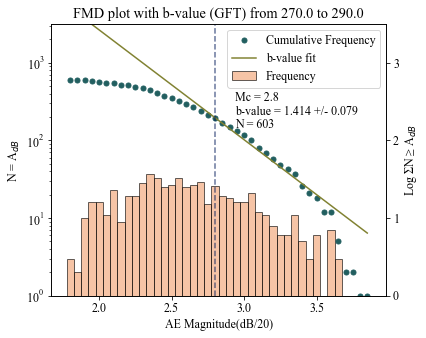

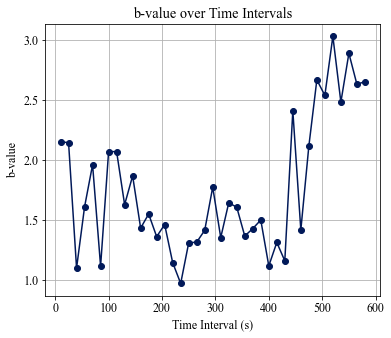

Lowest possible time interval with at least 50 hits: 10 seconds


In [2]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt

# Set plot size to be larger than default
plt.rcParams["figure.figsize"] = (6, 5)
plt.rcParams['font.family'] = 'serif'             # Set overall font family 
plt.rcParams['font.serif'] = ['Times New Roman']  # Try to prioritize Times New Roman
plt.rcParams.update({'legend.fontsize': 12})

font = {'family': 'serif',
        'size': 12}

plt.rc('font', **font)

# Constants / file-paths
RAW_DATA_FILE = 'AE-Filt-ch3.xlsx'  
OUTPUT_FILE = 'b-GFT-ch3-20s.xlsx'

# Read in the data
df = pd.read_excel(RAW_DATA_FILE, header=None, names=['Time', 'Amplitude'])

# Filter the data to include only rows where the time is less than 10 minutes
df = df[df['Time'] < 600.1]

# Divide amplitude by 20
df['Amplitude'] = df['Amplitude'] / 20

# Frequency-magnitude distribution function
def fmd(mag, mbin):
    minmag = math.floor(min(mag / mbin)) * mbin  # Lowest magnitude bin
    maxmag = math.ceil(max(mag / mbin)) * mbin  # Highest magnitude bin
    mi = np.arange(minmag, maxmag + mbin, mbin)  # Sequence of magnitude bins
    nbm = len(mi)  # No. of magnitude bins
    cumnbmag = np.zeros(nbm)  # Pre-allocate array for cumulative no. of events in mag bin and higher

    # Get cumulative no. of events in mag bin and higher
    for i in range(nbm):
        cumnbmag[i] = np.where(mag > mi[i] - mbin / 2)[0].shape[0]

    # Get no. of events in each mag bin:
    nbmag = abs(np.diff(np.append(cumnbmag, 0)))

    return mi, nbmag, cumnbmag  # Return magnitude bins, no. of events in bin, and cumulative no. of events

# Function to estimate b-value using maximum likelihood method
def b_est(mag, mbin, mc):
    mag_above_mc = mag[mag > round(mc, 1) - mbin / 2]  # Magnitudes for events larger than cut-off magnitude mc
    n = mag_above_mc.shape[0]  # No of. events larger than cut-off magnitude mc
    if n < 50:  # Ensure at least 50 events
        return np.nan, np.nan, np.nan, np.nan
    else:
        mbar = np.mean(mag_above_mc)  # Mean magnitude for events larger than cut-off magnitude mc
        b = math.log10(math.exp(1)) / (mbar - (mc - mbin / 2))  # b-value from Eq 3
        a = math.log10(n) + b * mc  # 'a-value' for Eq 2
        aki_unc = b / math.sqrt(n)  # Uncertainty estimate from Eq 4
        shibolt_unc = 2.3 * b ** 2 * math.sqrt(sum((mag_above_mc - mbar) ** 2) / (n * (n - 1)))  # Uncertainty estimate from Eq 5
        return a, b, aki_unc, shibolt_unc  # Return b-value and estimates of uncertainty

# Function to generate overlapping time intervals
def generate_intervals(start_time, end_time, interval_length, smoothing_percentage):
    intervals = []
    step = interval_length * (1 - smoothing_percentage)
    current_start = start_time
    while current_start + interval_length <= end_time:
        intervals.append((current_start, current_start + interval_length))
        current_start += step
    return intervals

# Function to get completeness magnitude with MAXC method
def get_maxc(mag, mbin):
    this_fmd = fmd(mag, mbin)  # FMD
    maxc = this_fmd[0][np.argmax(this_fmd[1])]  # Mag bin with highest no. of events
    return round(maxc, 1)

# Function to get completeness magnitude with GFT method
def get_gft(mag, mbin, interval):
    this_fmd = fmd(mag, mbin)  # FMD
    this_maxc = get_maxc(mag, mbin)  # Needed further down

    # Zeros to accommodate synthetic GR distributions for each magnitude bin
    a = np.zeros(this_fmd[0].shape[0])  # Pre-allocate array to accommodate a values from Eq 2
    b = np.zeros(this_fmd[0].shape[0])  # Pre-allocate array to accommodate b values from Eq 2 & 3
    R = np.zeros(this_fmd[0].shape[0])  # Pre-allocate array to accommodate R values from Eq 6

    # Loop through each magnitude bin, using it as cut-off magnitude
    for i in range(this_fmd[0].shape[0]):
        mi = round(this_fmd[0][i], 1)  # Cut-off magnitude
        try:
            a[i], b[i], tmp1, tmp2 = b_est(mag, mbin, mi)  # a and b-values for this cut-off magnitude
        except:
            continue
        synthetic_gr = 10**(a[i] - b[i]*this_fmd[0])  # Synthetic GR for a and b
        Bi = this_fmd[2][i:]  # B_i in Eq 6
        Si = synthetic_gr[i:]  # S_i in Eq 6
        R[i] = (sum(abs(Bi - Si)) / sum(Bi)) * 100  # Eq 6

    # Confidence levels to test
    R_to_test = [95, 90]  # (95% and 90% conf levels)

    GFT_test = [np.where(R <= (100 - conf_level))[0] for conf_level in R_to_test]  # Test whether R within confidence level
    mc = np.nan  # Initialize mc as NaN

    # Loop through and check first cut-off mag within confidence level
    for test in GFT_test:
        if len(test) > 0:
            mc = round(this_fmd[0][test[0]], 1)  # Use first cut-off magnitude within confidence level
            break

    if np.isnan(mc):  # If no GFT test passed, use MAXC
        mc = this_maxc
        print(f'No fits within confidence levels, using MAXC estimate for interval {interval[0]} to {interval[1]}')

    return mc, this_fmd[0], R

# Function to calculate b-values for specified intervals
def calculate_b_values(df, intervals, mbin=0.05):
    b_values = []
    for interval in intervals:
        start, end = interval
        subset = df[(df['Time'] >= start) & (df['Time'] < end)]
        if len(subset) >= 50:  # Ensure at least 50 hits
            mag = subset['Amplitude']
            cat_mi, cat_nbmag, cat_cumnbmag = fmd(mag, mbin)
            mc_gft, mag_bins, R_gft = get_gft(mag, mbin, interval)
            if np.isnan(mc_gft):
                mc_gft = get_maxc(mag, mbin)
            if mc_gft is not None:
                a, b, aki_unc, shibolt_unc = b_est(mag, mbin, mc_gft)
                b_values.append({
                    'start': start,
                    'end': end,
                    'a': a,
                    'b': b,
                    'aki_unc': aki_unc,
                    'shibolt_unc': shibolt_unc,
                    'mc': mc_gft,
                    'n': len(mag)
                })
    return b_values

# Function to plot b-values for specified intervals
def plot_b_values(b_values, start_plot, end_plot):
    for i, b_value in enumerate(b_values):
        if b_value['start'] >= start_plot and b_value['end'] <= end_plot:
            fig, ax1 = plt.subplots()
            mag = df[(df['Time'] >= b_value['start']) & (df['Time'] < b_value['end'])]['Amplitude']
            cat_mi, cat_nbmag, cat_cumnbmag = fmd(mag, 0.05)

            # Plot cat_nbmag as a bar chart
            ax1.bar(cat_mi, cat_nbmag, width=0.05, color='#f09d6b', edgecolor='black', linewidth=1, alpha=0.6, label='Frequency')

            # Superimpose the original plots
            ax1.plot(cat_mi, cat_cumnbmag, '.', markersize=10, label='Cumulative Frequency', color='#225f60')
            ax1.plot(cat_mi, (10 ** (b_value['a'] - (b_value['b'] * cat_mi))), label='b-value fit', color='#818232')

            # Vertical line for completeness magnitude
            ax1.vlines(b_value['mc'], ymin=1, ymax=10 ** math.ceil(math.log10(df.shape[0])), alpha=0.6, linestyles='dashed', color='#011959')

            # Set log scale for y-axis
            ax1.set_yscale('log')
            ax1.set_ylim(1, 10 ** 3.5)

            # Labels and title
            ax1.set_xlabel('AE Magnitude(dB/20)')
            ax1.set_ylabel('N = A$_{dB}$')
            ax1.set_title(f'FMD plot with b-value (GFT) from {b_value["start"]} to {b_value["end"]}')

            # Text annotations
            ax1.text(x=0.55, y=0.75, s=f"Mc = {round(b_value['mc'], 1)}", transform=ax1.transAxes, verticalalignment='top')
            ax1.text(x=0.55, y=0.70, s=f"b-value = {round(b_value['b'], 3)} +/- {round(b_value['shibolt_unc'], 3)}", transform=ax1.transAxes, verticalalignment='top')
            ax1.text(x=0.55, y=0.65, s=f"N = {b_value['n']}", transform=ax1.transAxes, verticalalignment='top')

            # Secondary axis for cumulative number of events (log ΣN)
            ax2 = ax1.twinx()
            ax2.set_ylabel('Log ΣN ≥ A$_{dB}$')
            ax2.set_ylim(ax1.get_ylim())
            ax2.grid(False)

            # Format secondary axis to show natural log
            ax2.set_yscale('log')
            ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0f}'.format(math.log10(y))))
            ax2.minorticks_off()

            fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.88))

            plt.xticks(np.arange(2, 4, 0.5))
            plt.savefig(f'GFT_plot2_{i}.png', dpi=300, bbox_inches='tight')
            plt.show()

# Function to plot b-value against time intervals
def plot_save_b_value_over_time(b_values):
    time_intervals = [(b_value['start'] + b_value['end']) / 2 for b_value in b_values]
    b_values_list = [b_value['b'] for b_value in b_values]
    
    plt.figure()
    plt.plot(time_intervals, b_values_list, marker='o', linestyle='-', color='#011959')
    plt.xlabel('Time Interval (s)')
    plt.ylabel('b-value')
    plt.title('b-value over Time Intervals')
    plt.grid(True)
    plt.show()

    # Convert the results list into a DataFrame
    results_df = pd.DataFrame(b_values)
    
    # Save the results to an Excel file
    results_df.to_excel(OUTPUT_FILE, index=False)

# Function to test the lowest possible time interval with current dataset
def find_lowest_interval(df, start_time, end_time, mbin=0.05, min_hits=50):
    interval_length = 10  # Start with 10 seconds
    smoothing_percentage = 0.25  # 25% smoothing

    while True:
        intervals = generate_intervals(start_time, end_time, interval_length, smoothing_percentage)
        valid_intervals = sum(1 for start, end in intervals if len(df[(df['Time'] >= start) & (df['Time'] < end)]) >= min_hits)
        if valid_intervals == len(intervals):
            return interval_length
        interval_length += 1

# Example usage
start_time = 0
end_time = df['Time'].max()
interval_length = 20  # You can customize this value
smoothing_percentage = 0.25  # no smoothing

intervals = generate_intervals(start_time, end_time, interval_length, smoothing_percentage)
b_values = calculate_b_values(df, intervals, mbin=0.05)

# Customize the plotting range - note: time of failure initiation 4:35 mm:ss means 275 s. 60 seconds before and after
start_plot = 270
end_plot = 290
plot_b_values(b_values, start_plot, end_plot)



# Plot b-value over time intervals
plot_save_b_value_over_time(b_values)

# Find the lowest possible time interval with current dataset
lowest_interval = find_lowest_interval(df, start_time, end_time, mbin=0.05, min_hits=50)
print(f"Lowest possible time interval with at least 50 hits: {lowest_interval} seconds")



No fits within confidence levels, using MAXC estimate for interval 420 to 440


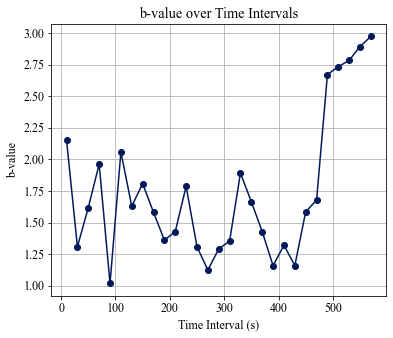

Lowest possible time interval with at least 50 hits: 10 seconds


In [3]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt

# Set plot size to be larger than default
plt.rcParams["figure.figsize"] = (6, 5)
plt.rcParams['font.family'] = 'serif'             # Set overall font family 
plt.rcParams['font.serif'] = ['Times New Roman']  # Try to prioritize Times New Roman
plt.rcParams.update({'legend.fontsize': 12})

font = {'family': 'serif',
        'size': 12}

plt.rc('font', **font)

# Constants / file-paths
RAW_DATA_FILE = 'AE-Filt-ch3.xlsx'  
OUTPUT_FILE = 'b-GFT-ch3-20sd.xlsx'

# Read in the data
df = pd.read_excel(RAW_DATA_FILE, header=None, names=['Time', 'Amplitude'])

# Filter the data to include only rows where the time is less than 10 minutes
df = df[df['Time'] < 600.1]

# Divide amplitude by 20
df['Amplitude'] = df['Amplitude'] / 20

# Frequency-magnitude distribution function
def fmd(mag, mbin):
    minmag = math.floor(min(mag / mbin)) * mbin  # Lowest magnitude bin
    maxmag = math.ceil(max(mag / mbin)) * mbin  # Highest magnitude bin
    mi = np.arange(minmag, maxmag + mbin, mbin)  # Sequence of magnitude bins
    nbm = len(mi)  # No. of magnitude bins
    cumnbmag = np.zeros(nbm)  # Pre-allocate array for cumulative no. of events in mag bin and higher

    # Get cumulative no. of events in mag bin and higher
    for i in range(nbm):
        cumnbmag[i] = np.where(mag > mi[i] - mbin / 2)[0].shape[0]

    # Get no. of events in each mag bin:
    nbmag = abs(np.diff(np.append(cumnbmag, 0)))

    return mi, nbmag, cumnbmag  # Return magnitude bins, no. of events in bin, and cumulative no. of events

# Function to estimate b-value using maximum likelihood method
def b_est(mag, mbin, mc):
    mag_above_mc = mag[mag > round(mc, 1) - mbin / 2]  # Magnitudes for events larger than cut-off magnitude mc
    n = mag_above_mc.shape[0]  # No of. events larger than cut-off magnitude mc
    if n < 50:  # Ensure at least 50 events
        return np.nan, np.nan, np.nan, np.nan
    else:
        mbar = np.mean(mag_above_mc)  # Mean magnitude for events larger than cut-off magnitude mc
        b = math.log10(math.exp(1)) / (mbar - (mc - mbin / 2))  # b-value from Eq 3
        a = math.log10(n) + b * mc  # 'a-value' for Eq 2
        aki_unc = b / math.sqrt(n)  # Uncertainty estimate from Eq 4
        shibolt_unc = 2.3 * b ** 2 * math.sqrt(sum((mag_above_mc - mbar) ** 2) / (n * (n - 1)))  # Uncertainty estimate from Eq 5
        return a, b, aki_unc, shibolt_unc  # Return b-value and estimates of uncertainty

# Function to generate overlapping time intervals
def generate_intervals(start_time, end_time, interval_length, smoothing_percentage):
    intervals = []
    step = interval_length * (1 - smoothing_percentage)
    current_start = start_time
    while current_start + interval_length <= end_time:
        intervals.append((current_start, current_start + interval_length))
        current_start += step
    return intervals

# Function to get completeness magnitude with MAXC method
def get_maxc(mag, mbin):
    this_fmd = fmd(mag, mbin)  # FMD
    maxc = this_fmd[0][np.argmax(this_fmd[1])]  # Mag bin with highest no. of events
    return round(maxc, 1)

# Function to get completeness magnitude with GFT method
def get_gft(mag, mbin, interval):
    this_fmd = fmd(mag, mbin)  # FMD
    this_maxc = get_maxc(mag, mbin)  # Needed further down

    # Zeros to accommodate synthetic GR distributions for each magnitude bin
    a = np.zeros(this_fmd[0].shape[0])  # Pre-allocate array to accommodate a values from Eq 2
    b = np.zeros(this_fmd[0].shape[0])  # Pre-allocate array to accommodate b values from Eq 2 & 3
    R = np.zeros(this_fmd[0].shape[0])  # Pre-allocate array to accommodate R values from Eq 6

    # Loop through each magnitude bin, using it as cut-off magnitude
    for i in range(this_fmd[0].shape[0]):
        mi = round(this_fmd[0][i], 1)  # Cut-off magnitude
        try:
            a[i], b[i], tmp1, tmp2 = b_est(mag, mbin, mi)  # a and b-values for this cut-off magnitude
        except:
            continue
        synthetic_gr = 10**(a[i] - b[i]*this_fmd[0])  # Synthetic GR for a and b
        Bi = this_fmd[2][i:]  # B_i in Eq 6
        Si = synthetic_gr[i:]  # S_i in Eq 6
        R[i] = (sum(abs(Bi - Si)) / sum(Bi)) * 100  # Eq 6

    # Confidence levels to test
    R_to_test = [95, 90]  # (95% and 90% conf levels)

    GFT_test = [np.where(R <= (100 - conf_level))[0] for conf_level in R_to_test]  # Test whether R within confidence level
    mc = np.nan  # Initialize mc as NaN

    # Loop through and check first cut-off mag within confidence level
    for test in GFT_test:
        if len(test) > 0:
            mc = round(this_fmd[0][test[0]], 1)  # Use first cut-off magnitude within confidence level
            break

    if np.isnan(mc):  # If no GFT test passed, use MAXC
        mc = this_maxc
        print(f'No fits within confidence levels, using MAXC estimate for interval {interval[0]} to {interval[1]}')

    return mc, this_fmd[0], R

# Function to calculate b-values for specified intervals
def calculate_b_values(df, intervals, mbin=0.05):
    b_values = []
    for interval in intervals:
        start, end = interval
        subset = df[(df['Time'] >= start) & (df['Time'] < end)]
        if len(subset) >= 50:  # Ensure at least 50 hits
            mag = subset['Amplitude']
            cat_mi, cat_nbmag, cat_cumnbmag = fmd(mag, mbin)
            mc_gft, mag_bins, R_gft = get_gft(mag, mbin, interval)
            if np.isnan(mc_gft):
                mc_gft = get_maxc(mag, mbin)
            if mc_gft is not None:
                a, b, aki_unc, shibolt_unc = b_est(mag, mbin, mc_gft)
                b_values.append({
                    'start': start,
                    'end': end,
                    'a': a,
                    'b': b,
                    'aki_unc': aki_unc,
                    'shibolt_unc': shibolt_unc,
                    'mc': mc_gft,
                    'n': len(mag)
                })
    return b_values

# Function to plot b-values for specified intervals
def plot_b_values(b_values, start_plot, end_plot):
    for i, b_value in enumerate(b_values):
        if b_value['start'] >= start_plot and b_value['end'] <= end_plot:
            fig, ax1 = plt.subplots()
            mag = df[(df['Time'] >= b_value['start']) & (df['Time'] < b_value['end'])]['Amplitude']
            cat_mi, cat_nbmag, cat_cumnbmag = fmd(mag, 0.05)

            # Plot cat_nbmag as a bar chart
            ax1.bar(cat_mi, cat_nbmag, width=0.05, color='#f09d6b', edgecolor='black', linewidth=1, alpha=0.6, label='Frequency')

            # Superimpose the original plots
            ax1.plot(cat_mi, cat_cumnbmag, '.', markersize=10, label='Cumulative Frequency', color='#225f60')
            ax1.plot(cat_mi, (10 ** (b_value['a'] - (b_value['b'] * cat_mi))), label='b-value fit', color='#818232')

            # Vertical line for completeness magnitude
            ax1.vlines(b_value['mc'], ymin=1, ymax=10 ** math.ceil(math.log10(df.shape[0])), alpha=0.6, linestyles='dashed', color='#011959')

            # Set log scale for y-axis
            ax1.set_yscale('log')
            ax1.set_ylim(1, 10 ** 3.5)

            # Labels and title
            ax1.set_xlabel('AE Magnitude(dB/20)')
            ax1.set_ylabel('N = A$_{dB}$')
            ax1.set_title(f'FMD plot with b-value (GFT) from {b_value["start"]} to {b_value["end"]}')

            # Text annotations
            ax1.text(x=0.55, y=0.75, s=f"Mc = {round(b_value['mc'], 1)}", transform=ax1.transAxes, verticalalignment='top')
            ax1.text(x=0.55, y=0.70, s=f"b-value = {round(b_value['b'], 3)} +/- {round(b_value['shibolt_unc'], 3)}", transform=ax1.transAxes, verticalalignment='top')
            ax1.text(x=0.55, y=0.65, s=f"N = {b_value['n']}", transform=ax1.transAxes, verticalalignment='top')

            # Secondary axis for cumulative number of events (log ΣN)
            ax2 = ax1.twinx()
            ax2.set_ylabel('Log ΣN ≥ A$_{dB}$')
            ax2.set_ylim(ax1.get_ylim())
            ax2.grid(False)

            # Format secondary axis to show natural log
            ax2.set_yscale('log')
            ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0f}'.format(math.log10(y))))
            ax2.minorticks_off()

            fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.88))

            plt.xticks(np.arange(2, 4, 0.5))
            plt.savefig(f'GFT_plot_{i}.png', dpi=300, bbox_inches='tight')
            plt.show()

# Function to plot b-value against time intervals
def plot_save_b_value_over_time(b_values):
    time_intervals = [(b_value['start'] + b_value['end']) / 2 for b_value in b_values]
    b_values_list = [b_value['b'] for b_value in b_values]
    
    plt.figure()
    plt.plot(time_intervals, b_values_list, marker='o', linestyle='-', color='#011959')
    plt.xlabel('Time Interval (s)')
    plt.ylabel('b-value')
    plt.title('b-value over Time Intervals')
    plt.grid(True)
    plt.show()

    # Convert the results list into a DataFrame
    results_df = pd.DataFrame(b_values)
    
    # Save the results to an Excel file
    results_df.to_excel(OUTPUT_FILE, index=False)

# Function to test the lowest possible time interval with current dataset
def find_lowest_interval(df, start_time, end_time, mbin=0.05, min_hits=50):
    interval_length = 10  # Start with 10 seconds
    smoothing_percentage = 0.25  # 25% smoothing

    while True:
        intervals = generate_intervals(start_time, end_time, interval_length, smoothing_percentage)
        valid_intervals = sum(1 for start, end in intervals if len(df[(df['Time'] >= start) & (df['Time'] < end)]) >= min_hits)
        if valid_intervals == len(intervals):
            return interval_length
        interval_length += 1

# Example usage
start_time = 0
end_time = df['Time'].max()
interval_length = 20  # You can customize this value
smoothing_percentage = 0  # no smoothing

intervals = generate_intervals(start_time, end_time, interval_length, smoothing_percentage)
b_values = calculate_b_values(df, intervals, mbin=0.05)

# Customize the plotting range - note: time of failure initiation 4:35 mm:ss means 275 s. 60 seconds before and after
start_plot = 270
end_plot = 290
plot_b_values(b_values, start_plot, end_plot)



# Plot b-value over time intervals
plot_save_b_value_over_time(b_values)

# Find the lowest possible time interval with current dataset
lowest_interval = find_lowest_interval(df, start_time, end_time, mbin=0.05, min_hits=50)
print(f"Lowest possible time interval with at least 50 hits: {lowest_interval} seconds")

